In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")
engine = create_engine(os.getenv("DATABASE_URL"), pool_pre_ping=True, pool_recycle=300)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

bookings = pd.read_sql("SELECT * FROM fact_bookings", engine)
daily = pd.read_sql("SELECT * FROM v_daily_property_kpi", engine)

print(bookings.shape, daily.shape)

(134590, 16) (2300, 16)


*Data quality*. The five source files load with no orphan keys, no duplicate booking IDs and no impossible stay dates — all verified by the SQL check suite in sql/05_checks.sql. Two genuine problems surfaced: the day_type column misspelled "weekday" as "weekeday" in all 65 weekday rows, corrected during transformation; and property 16559 is labelled Mumbai while every other 165xx property is in Delhi, which looks like a mislabel and puts two Atliq Exoticas in Mumbai. ratings_given is missing for 57.9% of bookings, so any average-rating metric describes only the guests who chose to rate.

In [2]:
quality = pd.DataFrame({
    "dtype": bookings.dtypes.astype(str),
    "nulls": bookings.isna().sum(),
    "null_pct": (100 * bookings.isna().mean()).round(1),
    "distinct": bookings.nunique(),
})

status_mix = bookings["booking_status"].value_counts(normalize=True).mul(100).round(1)

display(quality)
display(status_mix)


,dtype,nulls,null_pct,distinct
booking_id,str,0,0.0,134590
property_id,int64,0,0.0,25
booking_date,object,0,0.0,116
check_in_date,object,0,0.0,92
checkout_date,object,0,0.0,97
no_guests,int64,0,0.0,6
room_category,str,0,0.0,4
booking_platform,str,0,0.0,7
ratings_given,float64,77907,57.9,5
booking_status,str,0,0.0,3


booking_status
Checked Out    70.1
Cancelled      24.8
No Show         5.0
Name: proportion, dtype: float64

Weekend demand is the dominant pattern. Occupancy runs 51–52% on weekdays against 73–74% at weekends, and RevPAR moves from about ₹6,500 to about ₹9,400. The gap is nearly identical for Business and Luxury properties, which is unusual — business hotels normally fill mid-week — and suggests the chain's demand is leisure-driven across both categories. Weekday capacity is the clearest revenue opportunity in the data.

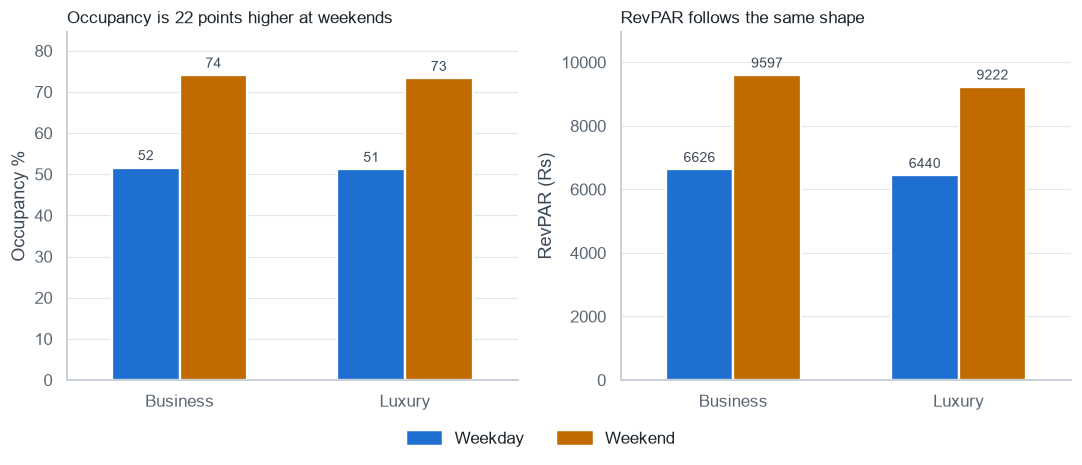

,category,day_type,occupancy_pct,revpar
0,Business,weekday,51.6,6626.2
1,Business,weekend,74.1,9596.9
2,Luxury,weekday,51.2,6439.7
3,Luxury,weekend,73.3,9221.6


In [5]:
PALETTE = {"weekday": "#1f6fd0", "weekend": "#c06a00"}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e3e6ea",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#c8ced6",
    "axes.labelcolor": "#3d4a57",
    "text.color": "#1c242c",
    "xtick.color": "#5a6672",
    "ytick.color": "#5a6672",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

os.makedirs("../docs/figures", exist_ok=True)

dates = pd.read_sql("SELECT date_actual, day_type, week_no FROM dim_date", engine)
daily["stay_date"] = pd.to_datetime(daily["stay_date"])
dates["date_actual"] = pd.to_datetime(dates["date_actual"])
daily = daily.merge(dates, left_on="stay_date", right_on="date_actual", how="left")

occ = (daily.groupby(["category", "day_type"], as_index=False)
       .agg(capacity=("capacity", "sum"),
            booked=("successful_bookings", "sum"),
            revenue=("revenue_realized", "sum")))
occ["occupancy_pct"] = 100 * occ["booked"] / occ["capacity"]
occ["revpar"] = occ["revenue"] / occ["capacity"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, metric, label in zip(axes, ["occupancy_pct", "revpar"], ["Occupancy %", "RevPAR (Rs)"]):
    sns.barplot(data=occ, x="category", y=metric, hue="day_type", palette=PALETTE,
                ax=ax, width=0.6, saturation=1, edgecolor="white", linewidth=1.5)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f", padding=3, fontsize=9, color="#3d4a57")
    ax.set(xlabel="", ylabel=label)
    ax.set_axisbelow(True)
    ax.margins(y=0.14)
    ax.legend_.remove()

axes[0].set_title("Occupancy is 22 points higher at weekends", loc="left", fontsize=11)
axes[1].set_title("RevPAR follows the same shape", loc="left", fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[k]) for k in ["weekday", "weekend"]]
fig.legend(handles, ["Weekday", "Weekend"], loc="lower center", ncol=2,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../docs/figures/occupancy_by_daytype.png", dpi=200, bbox_inches="tight")
plt.show()

occ[["category", "day_type", "occupancy_pct", "revpar"]].round(1)


The city gap is a pricing gap, not a demand gap. Occupancy sits in a narrow 56–61% band across all four cities, so every market fills its rooms at roughly the same rate. ADR does not: Mumbai averages ₹15,387 against Hyderabad's ₹9,322. RevPAR therefore follows rate almost exactly, and Hyderabad's ₹5,414 is 39% below Mumbai's ₹8,907 despite comparable occupancy. Delhi is the clearest case — it has the highest occupancy of the four and still ranks second on RevPAR, because its rooms are priced ₹3,200 below Mumbai's.

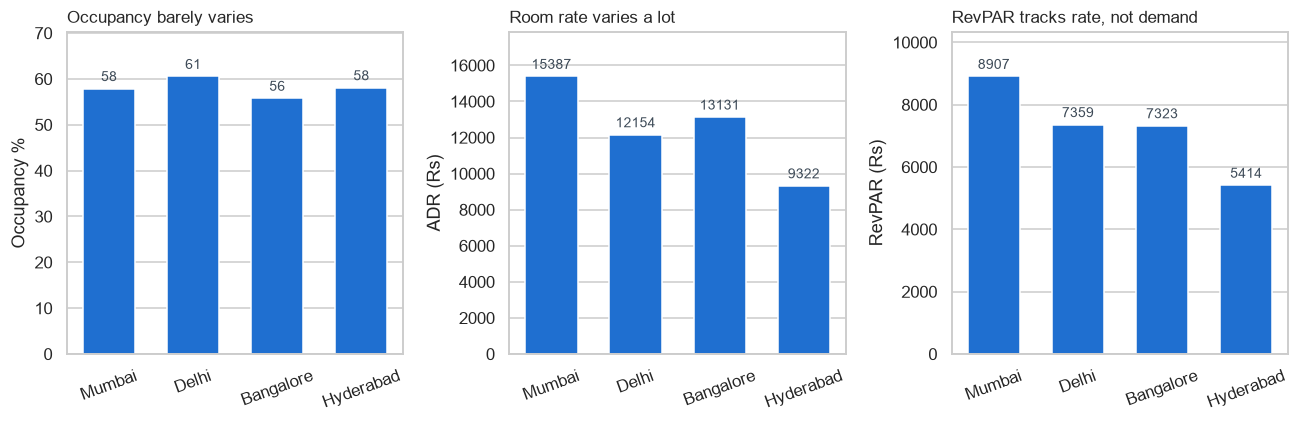

,city,occupancy_pct,adr,revpar
3,Mumbai,57.9,15387.0,8906.7
1,Delhi,60.5,12153.9,7358.8
0,Bangalore,55.8,13130.8,7323.0
2,Hyderabad,58.1,9322.2,5413.7


In [7]:
city = (daily.groupby("city", as_index=False)
        .agg(capacity=("capacity", "sum"),
             booked=("successful_bookings", "sum"),
             bookings=("total_bookings", "sum"),
             revenue=("revenue_realized", "sum")))
city["occupancy_pct"] = 100 * city["booked"] / city["capacity"]
city["adr"] = city["revenue"] / city["bookings"]
city["revpar"] = city["revenue"] / city["capacity"]
city = city.sort_values("revpar", ascending=False)

metrics = [("occupancy_pct", "Occupancy %"), ("adr", "ADR (Rs)"), ("revpar", "RevPAR (Rs)")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (m, label) in zip(axes, metrics):
    sns.barplot(data=city, x="city", y=m, ax=ax, color="#1f6fd0", width=0.62, saturation=1)
    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=9, color="#3d4a57")
    ax.set(xlabel="", ylabel=label)
    ax.set_axisbelow(True)
    ax.margins(y=0.16)
    ax.tick_params(axis="x", rotation=20)

axes[0].set_title("Occupancy barely varies", loc="left", fontsize=11)
axes[1].set_title("Room rate varies a lot", loc="left", fontsize=11)
axes[2].set_title("RevPAR tracks rate, not demand", loc="left", fontsize=11)

plt.tight_layout()
plt.savefig("../docs/figures/revpar_by_city.png", dpi=200, bbox_inches="tight")
plt.show()

city[["city", "occupancy_pct", "adr", "revpar"]].round(1)  


Cancellation behaviour carries no signal. Across fifteen segments — four lead-time buckets, seven booking platforms and four room classes — the share of bookings that never checked out stays between 29.4% and 30.2%, against an overall rate of 29.9%. No channel is riskier, no room class is riskier, and booking further ahead does not make a guest more likely to cancel. Combined with lead_time_days taking only eleven distinct values, this indicates cancellations were assigned independently of booking attributes when the dataset was generated. The practical consequence is that cancellation cannot be predicted or targeted from this data; the 29.9% loss should be treated as a fixed rate applied uniformly, and revenue-protection effort belongs in pricing rather than in channel or lead-time policy.

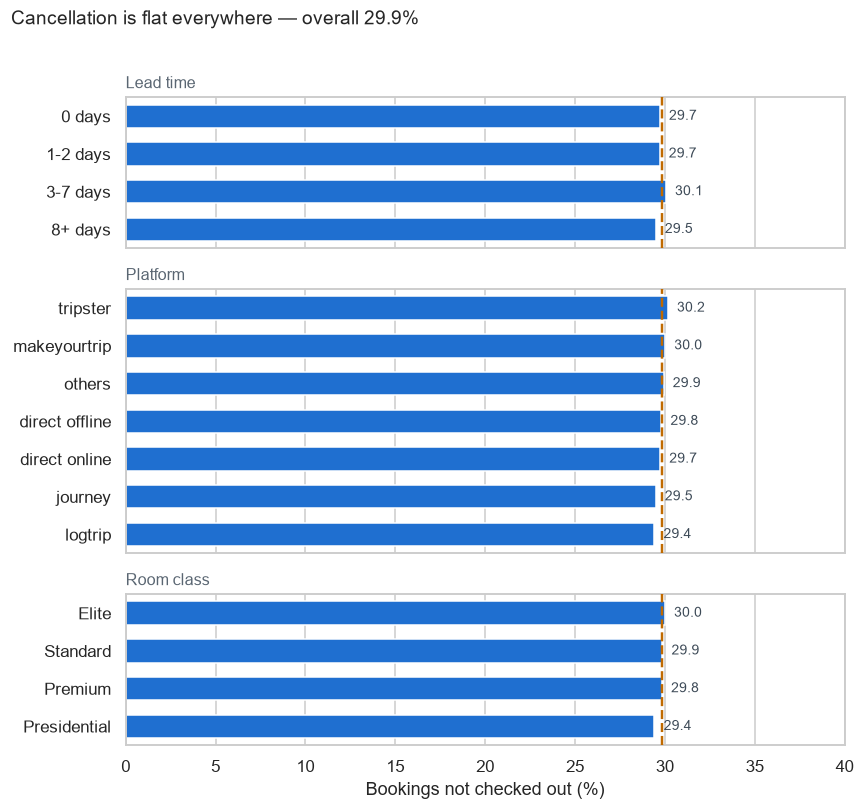

,bookings,lost_rate_pct
booking_platform,,
direct offline,6755,29.80
direct online,13379,29.73
journey,8106,29.48
logtrip,14756,29.41
makeyourtrip,26898,30.01
others,55066,29.93
tripster,9630,30.17


In [8]:
room_map = pd.read_sql("SELECT room_id, room_class FROM dim_rooms", engine)
bookings = bookings.merge(room_map, left_on="room_category", right_on="room_id", how="left")
bookings["lead_bucket"] = pd.cut(bookings["lead_time_days"], bins=[-1, 0, 2, 7, 100],
                                 labels=["0 days", "1-2 days", "3-7 days", "8+ days"])

dims = [("lead_bucket", "Lead time"), ("booking_platform", "Platform"), ("room_class", "Room class")]
overall = 100 * (bookings["booking_status"] != "Checked Out").mean()

fig, axes = plt.subplots(3, 1, figsize=(8, 7.5), sharex=True,
                         gridspec_kw={"height_ratios": [4, 7, 4]})
for ax, (dim, label) in zip(axes, dims):
    g = (bookings.groupby(dim, observed=True)
         .agg(bookings=("booking_id", "count"),
              lost=("booking_status", lambda s: (s != "Checked Out").sum()))
         .reset_index())
    g["lost_rate_pct"] = 100 * g["lost"] / g["bookings"]
    g = g.sort_values("lost_rate_pct", ascending=False)
    sns.barplot(data=g, x="lost_rate_pct", y=dim, ax=ax, color="#1f6fd0", saturation=1, width=0.62)
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=6, fontsize=9, color="#3d4a57")
    ax.axvline(overall, color="#c06a00", ls="--", lw=1.6, zorder=3)
    ax.set(xlabel="", ylabel="")
    ax.set_title(label, loc="left", fontsize=10.5, color="#5a6672")
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Bookings not checked out (%)")
axes[0].set_xlim(0, 40)
fig.suptitle(f"Cancellation is flat everywhere — overall {overall:.1f}%", x=0.02, ha="left", fontsize=12.5)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../docs/figures/cancellation_flatness.png", dpi=200, bbox_inches="tight")
plt.show()

flat_summary = bookings.groupby("booking_platform").agg(
    bookings=("booking_id", "count"),
    lost_rate_pct=("booking_status", lambda s: round(100 * (s != "Checked Out").mean(), 2)),
)
flat_summary  

Revenue concentrates above the volume line. Standard and Elite rooms account for 65% of bookings but only 51% of revenue, while Premium and Presidential take 35% of bookings and 49% of revenue. The crossover happens at Premium — it is the first class where revenue share exceeds booking share. Presidential is the sharpest case: 11.9% of bookings produce 22.0% of revenue, at an ADR of ₹23,440 against Standard's ₹8,052. Since cancellation rates are identical across classes, the upper two classes are strictly more valuable per room sold, which argues for upgrade and upsell effort rather than discounting to fill Standard inventory.

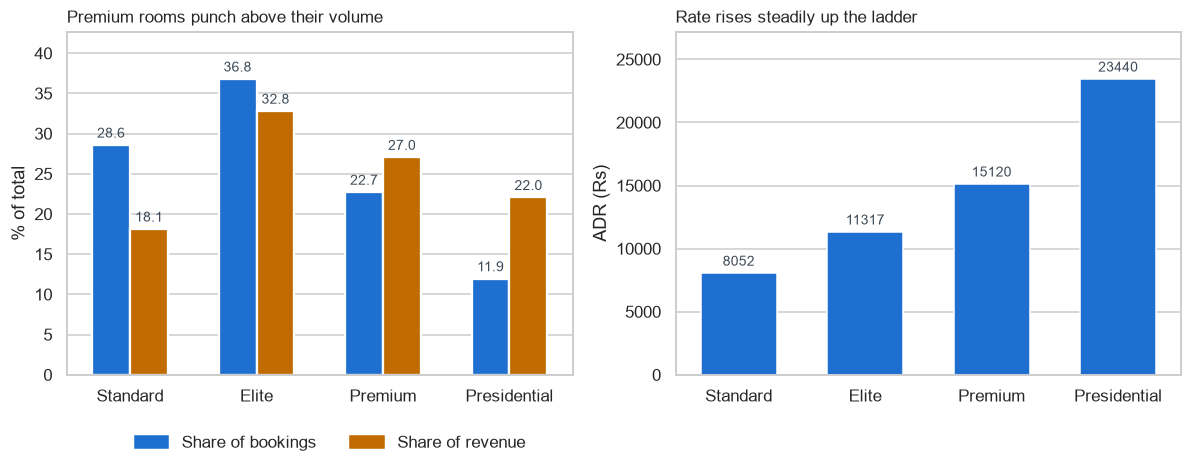

,room_class,bookings,Share of bookings,Share of revenue,adr
3,Standard,38446,28.6,18.1,8052.4
0,Elite,49505,36.8,32.8,11317.5
1,Premium,30566,22.7,27.0,15120.3
2,Presidential,16073,11.9,22.0,23440.1


In [9]:
order = ["Standard", "Elite", "Premium", "Presidential"]
PALETTE2 = {"Share of bookings": "#1f6fd0", "Share of revenue": "#c06a00"}

room = bookings.groupby("room_class", as_index=False).agg(
    bookings=("booking_id", "count"), revenue=("revenue_realized", "sum"))
room["Share of bookings"] = 100 * room["bookings"] / room["bookings"].sum()
room["Share of revenue"] = 100 * room["revenue"] / room["revenue"].sum()
room["adr"] = room["revenue"] / room["bookings"]
room["room_class"] = pd.Categorical(room["room_class"], categories=order, ordered=True)
room = room.sort_values("room_class")

melted = room.melt(id_vars="room_class", value_vars=["Share of bookings", "Share of revenue"],
                   var_name="measure", value_name="pct")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=melted, x="room_class", y="pct", hue="measure", palette=PALETTE2,
            ax=axes[0], width=0.6, saturation=1, edgecolor="white", linewidth=1.5)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.1f", padding=3, fontsize=9, color="#3d4a57")
axes[0].set(xlabel="", ylabel="% of total")
axes[0].margins(y=0.16)
axes[0].set_axisbelow(True)
axes[0].legend_.remove()
axes[0].set_title("Premium rooms punch above their volume", loc="left", fontsize=11)

sns.barplot(data=room, x="room_class", y="adr", ax=axes[1], color="#1f6fd0", width=0.6, saturation=1)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3, fontsize=9, color="#3d4a57")
axes[1].set(xlabel="", ylabel="ADR (Rs)")
axes[1].margins(y=0.16)
axes[1].set_axisbelow(True)
axes[1].set_title("Rate rises steadily up the ladder", loc="left", fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE2[k]) for k in PALETTE2]
fig.legend(handles, list(PALETTE2), loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.28, -0.03))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("../docs/figures/room_class_ladder.png", dpi=200, bbox_inches="tight")
plt.show()

room[["room_class", "bookings", "Share of bookings", "Share of revenue", "adr"]].round(1)  


The missing ratings are structural, not random — and they hide a trap. Not one cancelled or no-show booking carries a rating, because those guests never stayed. The 57.9% missing rate is therefore 40% who could not rate plus 40% of checked-out guests who chose not to. Among guests who did stay, response is 60% and is uniform across every platform (42.0–42.8% of all bookings) and room class (41.7–42.8%), so there is no channel or segment bias in who responds.

The trap: guests with a rating show a mean realised revenue of ₹14,927 against ₹11,073 for those without, which looks like "guests who rate spend more." They do not. Cancelled bookings realise only 40% of their generated revenue under the refund rule and can never carry a rating, so the entire ₹3,854 difference is the refund policy, not guest behaviour. The correct denominator for any average-rating metric is the 94,411 checked-out bookings, and the resulting 3.62 average must be labelled as the rating from guests who stayed — not from all bookings.

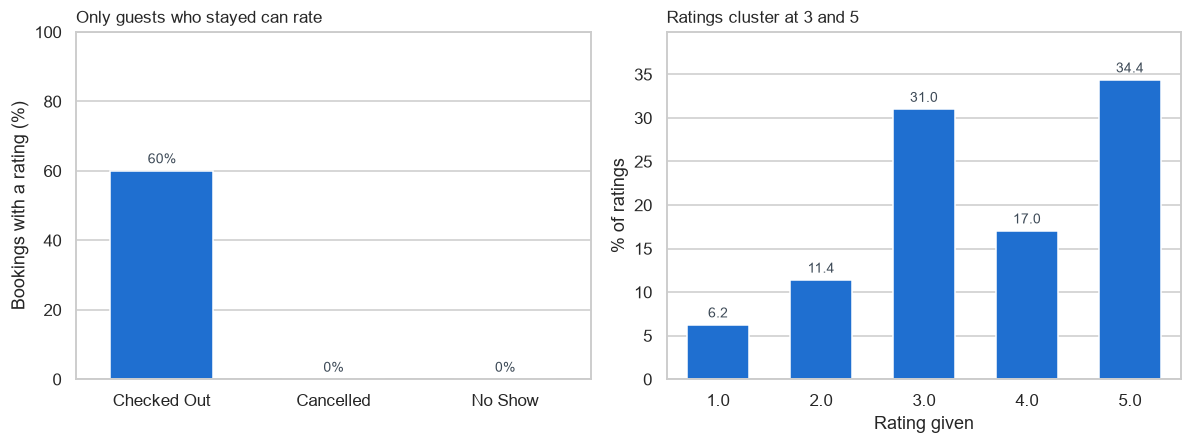

has_rating
False    11073.0
True     14927.0
Name: revenue_realized, dtype: float64

In [10]:
bookings["has_rating"] = bookings["ratings_given"].notna()

cov = bookings.groupby("booking_status", as_index=False)["has_rating"].mean()
cov["coverage_pct"] = 100 * cov["has_rating"]
cov = cov.sort_values("coverage_pct", ascending=False)

dist = bookings["ratings_given"].value_counts(normalize=True).mul(100).sort_index().reset_index()
dist.columns = ["rating", "pct"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=cov, x="booking_status", y="coverage_pct", ax=axes[0],
            color="#1f6fd0", width=0.6, saturation=1)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f%%", padding=3, fontsize=9, color="#3d4a57")
axes[0].set(xlabel="", ylabel="Bookings with a rating (%)", ylim=(0, 100))
axes[0].set_axisbelow(True)
axes[0].set_title("Only guests who stayed can rate", loc="left", fontsize=11)

sns.barplot(data=dist, x="rating", y="pct", ax=axes[1], color="#1f6fd0", width=0.6, saturation=1)
axes[1].bar_label(axes[1].containers[0], fmt="%.1f", padding=3, fontsize=9, color="#3d4a57")
axes[1].set(xlabel="Rating given", ylabel="% of ratings")
axes[1].margins(y=0.16)
axes[1].set_axisbelow(True)
axes[1].set_title("Ratings cluster at 3 and 5", loc="left", fontsize=11)

plt.tight_layout()
plt.savefig("../docs/figures/rating_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

bookings.groupby("has_rating")["revenue_realized"].mean().round(0)